Julieta Madrigal Flores

Rodolfo Del Castillo Wilches

In [ ]:
# payoff_estrategia: calcula el P&L neto al vencimiento
# graficar_estrategia: visualiza el diagrama de payoff

import numpy as np
import matplotlib.pyplot as plt

def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total

def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(10, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

    if S0:
        plt.axvline(S0, color='purple', linewidth=0.8,
                    linestyle='-.', label=f'S0={S0:.2f}')

    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)

    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## OBTENCIÓN DE DATOS REALES DE SPY

In [ ]:
# - Precio actual S0
# - Opciones calls y puts para la fecha de vencimiento
# - Primas para strikes ATM y OTM

import yfinance as yf

# Obtener precio actual de SPY
ticker = yf.Ticker("SPY")
S0 = ticker.history(period="1d")['Close'].iloc[-1]
print(f"\nPrecio actual de SPY (S0): ${S0:.2f}")

# Fecha de vencimiento
expiry = "2026-04-17"

# Obtener la cadena de opciones
opt_chain = ticker.option_chain(expiry)
calls = opt_chain.calls
puts = opt_chain.puts

# Encontrar strikes cercanos al dinero (ATM)
strikes_calls = calls['strike'].values
strikes_puts = puts['strike'].values

# Strike ATM, el más cercano a S0
K_atm = strikes_calls[np.argmin(np.abs(strikes_calls - S0))]
print(f"\nStrike ATM: ${K_atm:.2f}")

# Para bull spread: strikes ligeramente OTM con aproximadamente a $15 de distancia
K_bull_low = strikes_calls[np.argmin(np.abs(strikes_calls - (S0 - 15)))]
K_bull_high = strikes_calls[np.argmin(np.abs(strikes_calls - (S0 + 15)))]
print(f"Bull spread strikes: ${K_bull_low:.2f} - ${K_bull_high:.2f}")

# Para bear spread: strikes ligeramente OTM
K_bear_high = strikes_puts[np.argmin(np.abs(strikes_puts - (S0 + 15)))]
K_bear_low = strikes_puts[np.argmin(np.abs(strikes_puts - (S0 - 15)))]
print(f"Bear spread strikes: ${K_bear_low:.2f} - ${K_bear_high:.2f}")

# Obtener primas
call_atm = calls[calls['strike'] == K_atm]['lastPrice'].values[0]
put_atm = puts[puts['strike'] == K_atm]['lastPrice'].values[0]
call_bull_low = calls[calls['strike'] == K_bull_low]['lastPrice'].values[0]
call_bull_high = calls[calls['strike'] == K_bull_high]['lastPrice'].values[0]
put_bear_high = puts[puts['strike'] == K_bear_high]['lastPrice'].values[0]
put_bear_low = puts[puts['strike'] == K_bear_low]['lastPrice'].values[0]

print(f"\nPrimas obtenidas:")
print(f"  Call ATM (K={K_atm:.2f}): ${call_atm:.2f}")
print(f"  Put ATM (K={K_atm:.2f}): ${put_atm:.2f}")
print(f"  Call {K_bull_low:.2f}: ${call_bull_low:.2f}")
print(f"  Call {K_bull_high:.2f}: ${call_bull_high:.2f}")
print(f"  Put {K_bear_high:.2f}: ${put_bear_high:.2f}")
print(f"  Put {K_bear_low:.2f}: ${put_bear_low:.2f}")


Precio actual de SPY (S0): $673.20

Strike ATM: $673.00
Bull spread strikes: $658.00 - $688.00
Bear spread strikes: $658.00 - $688.00

Primas obtenidas:
  Call ATM (K=673.00): $7.91
  Put ATM (K=673.00): $7.20
  Call 658.00: $19.05
  Call 688.00: $1.40
  Put 688.00: $15.83
  Put 658.00: $3.22


## LONG STRADDLE


LONG STRADDLE
Costo total        : $15.11
Break-even sup.    : $688.11
Break-even inf.    : $657.89
Pérdida máxima     : $-15.11  (si ST =673.0)


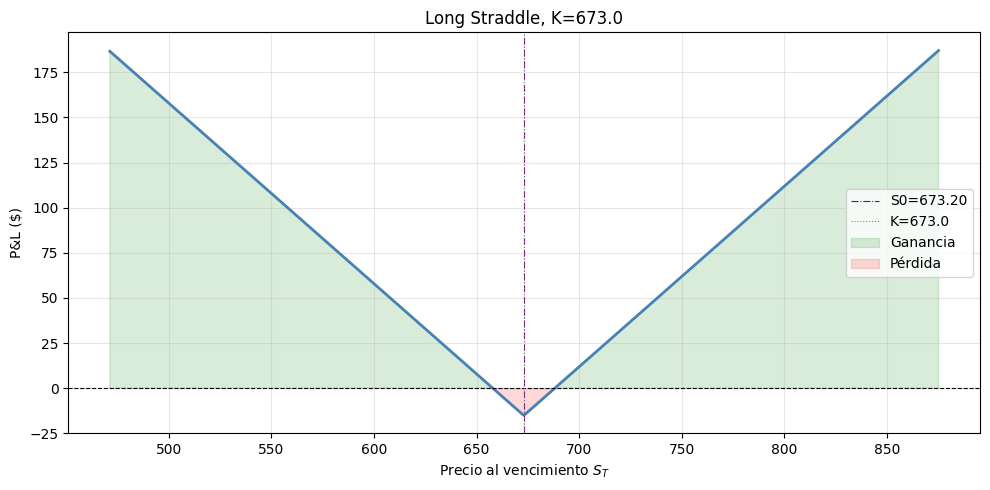

In [ ]:
# Compra simultánea de call y put con el MISMO strike (ATM)

# Rango de precios para el gráfico = 70% a 130% del precio actual
S_range = np.linspace(S0 * 0.7, S0 * 1.3, 500)

# Datos de la estrategia (usando los valores reales obtenidos)
K = K_atm
C = call_atm
P = put_atm

# Construcción de la estrategia - EXACTAMENTE como en Clase 21
legs_straddle = [
    {'tipo': 'call', 'K': K, 'prima': C, 'posicion': +1},
    {'tipo': 'put',  'K': K, 'prima': P, 'posicion': +1},
]

# Cálculo del P&L
pnl = payoff_estrategia(S_range, legs_straddle)

# Impresión de resultados - MISMOS prints que en Clase 21
print("\n" + "=" * 70)
print("LONG STRADDLE")
print("=" * 70)
print(f"Costo total        : ${C+P:.2f}")
print(f"Break-even sup.    : ${K+C+P:.2f}")
print(f"Break-even inf.    : ${K-C-P:.2f}")
print(f"Pérdida máxima     : ${-(C+P):.2f}  (si ST ={K})")

# Gráfico - MISMA llamada que en Clase 21
graficar_estrategia(S_range, pnl, f'Long Straddle, K={K}', S0=S0, K_lines=[(K, f'K={K}')])


LONG STRANGLE
Costo total        : $4.62  (vs $15.11 del straddle)
Break-even sup.    : $692.62
Break-even inf.    : $653.38


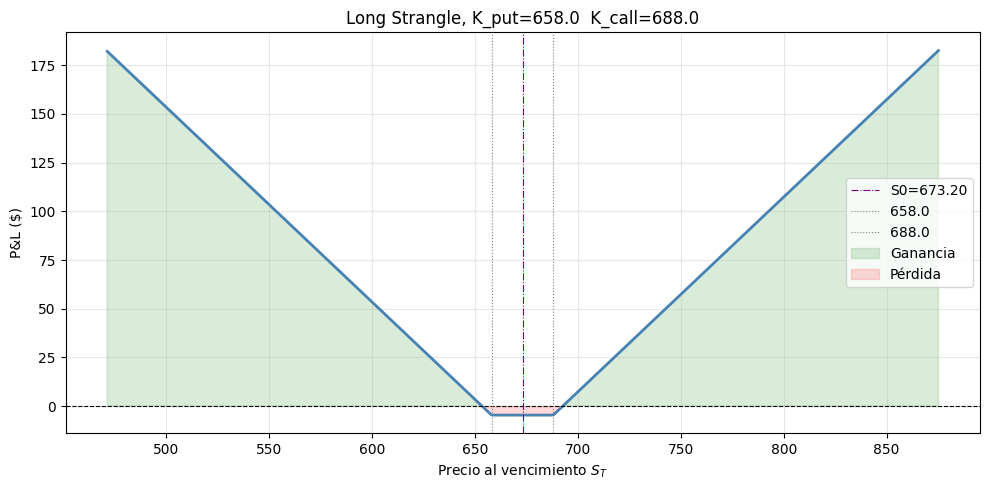

In [ ]:
# Compra de call y put con strikes DIFERENTES (ambos OTM)
# Más barato que el straddle, pero necesita mayor movimiento

# Datos de la estrategia (usando valores reales)
K_call = K_bull_high   # Call OTM por arriba
K_put = K_bear_low     # Put OTM por abajo
C_otm = call_bull_high
P_otm = put_bear_low

# Construcción de la estrategia - EXACTAMENTE como en Clase 21
legs_strangle = [
    {'tipo': 'call', 'K': K_call, 'prima': C_otm, 'posicion': +1},
    {'tipo': 'put',  'K': K_put,  'prima': P_otm,  'posicion': +1},
]

# Cálculo del P&L
pnl = payoff_estrategia(S_range, legs_strangle)

# Impresión de resultados - MISMOS prints que en Clase 21
print("\n" + "=" * 70)
print("LONG STRANGLE")
print("=" * 70)
print(f"Costo total        : ${C_otm+P_otm:.2f}  (vs ${C+P:.2f} del straddle)")
print(f"Break-even sup.    : ${K_call+C_otm+P_otm:.2f}")
print(f"Break-even inf.    : ${K_put-C_otm-P_otm:.2f}")

# Gráfico - MISMA llamada que en Clase 21
graficar_estrategia(S_range, pnl, f'Long Strangle, K_put={K_put}  K_call={K_call}',
                    S0=S0, K_lines=[(K_put, f'{K_put}'), (K_call, f'{K_call}')])

## BULL CALL SPREAD


BULL CALL SPREAD
Prima neta pagada  : $17.65
Ganancia máxima    : $12.35  (si ST ≥688.0)
Pérdida máxima     : $-17.65  (si ST ≤658.0)
Break-even         : $675.65


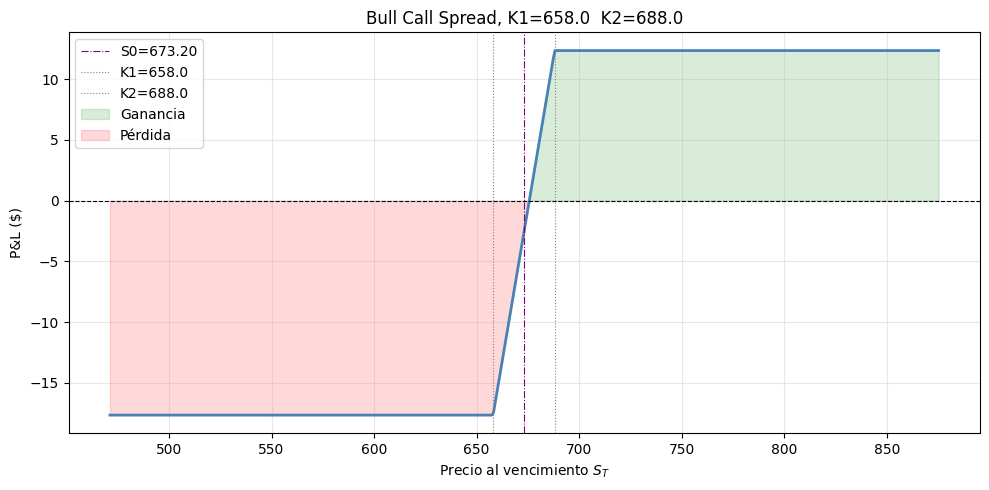

In [ ]:
# Compra de call K1 (bajo) + venta de call K2 (alto)
# Vista del mercado: "Subirá moderadamente, pero no más allá de K2"

# Datos de la estrategia (usando valores reales)
K1 = K_bull_low      # Strike comprado (más bajo)
K2 = K_bull_high     # Strike vendido (más alto)
C1 = call_bull_low   # Prima pagada
C2 = call_bull_high  # Prima recibida

# Construcción de la estrategia - EXACTAMENTE como en Clase 21
legs_bull = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -1},]

# Cálculo del P&L
pnl = payoff_estrategia(S_range, legs_bull)
prima_neta = C1 - C2

# Impresión de resultados - MISMOS prints que en Clase 21
print("\n" + "=" * 70)
print("BULL CALL SPREAD")
print("=" * 70)
print(f"Prima neta pagada  : ${prima_neta:.2f}")
print(f"Ganancia máxima    : ${(K2-K1)-prima_neta:.2f}  (si ST ≥{K2})")
print(f"Pérdida máxima     : ${-prima_neta:.2f}  (si ST ≤{K1})")
print(f"Break-even         : ${K1+prima_neta:.2f}")

# Gráfico - MISMA llamada que en Clase 21
graficar_estrategia(S_range, pnl, f'Bull Call Spread, K1={K1}  K2={K2}',
                    S0=S0, K_lines=[(K1, f'K1={K1}'), (K2, f'K2={K2}')])

##  BEAR PUT SPREAD


BEAR PUT SPREAD
Prima neta pagada  : $12.61
Ganancia máxima    : $17.39  (si ST ≤658.0)
Pérdida máxima     : $-12.61  (si ST ≥688.0)
Break-even         : $675.39


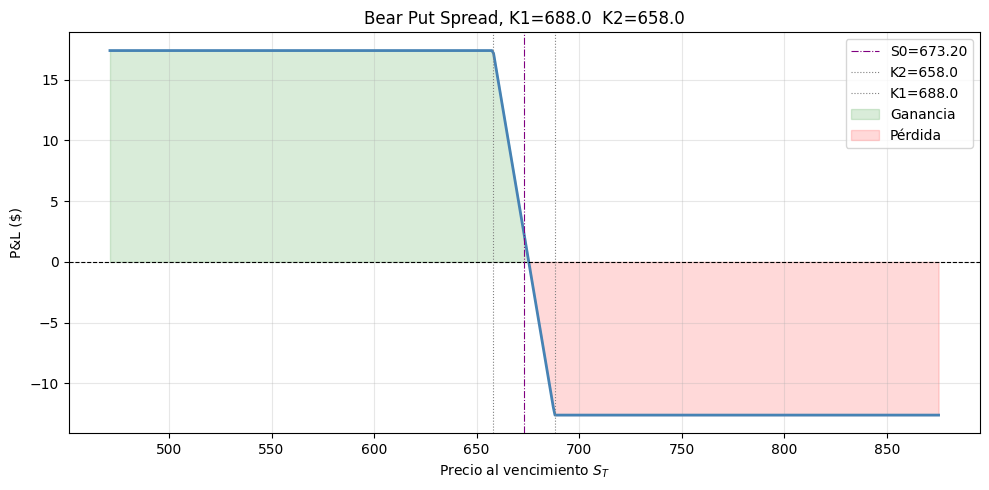

In [ ]:
# Compra de put K1 (alto) + venta de put K2 (bajo)
# Vista del mercado: "Bajará moderadamente, pero no más allá de K2"

# Datos de la estrategia (usando valores reales)
K1 = K_bear_high     # Strike comprado (más alto)
K2 = K_bear_low      # Strike vendido (más bajo)
P1 = put_bear_high   # Prima pagada
P2 = put_bear_low    # Prima recibida

# Construcción de la estrategia - EXACTAMENTE como en Clase 21
legs_bear = [
    {'tipo': 'put', 'K': K1, 'prima': P1, 'posicion': +1},
    {'tipo': 'put', 'K': K2, 'prima': P2, 'posicion': -1},
]

# Cálculo del P&L
pnl = payoff_estrategia(S_range, legs_bear)
prima_neta = P1 - P2

# Impresión de resultados - MISMOS prints que en Clase 21
print("\n" + "=" * 70)
print("BEAR PUT SPREAD")
print("=" * 70)
print(f"Prima neta pagada  : ${prima_neta:.2f}")
print(f"Ganancia máxima    : ${(K1-K2)-prima_neta:.2f}  (si ST ≤{K2})")
print(f"Pérdida máxima     : ${-prima_neta:.2f}  (si ST ≥{K1})")
print(f"Break-even         : ${K1-prima_neta:.2f}")

# Gráfico - MISMA llamada que en Clase 21
graficar_estrategia(S_range, pnl, f'Bear Put Spread, K1={K1}  K2={K2}',
                    S0=S0, K_lines=[(K2, f'K2={K2}'), (K1, f'K1={K1}')])

## TABLA RESUMEN

In [ ]:
# Consolidación de costos, pérdidas máximas,
# ganancias máximas y break-evens de las 4 estrategias

import pandas as pd

# Recalcular valores para la tabla (usando las variables de las partes anteriores)
costo_straddle = C + P
costo_strangle = C_otm + P_otm
prima_neta_bull = C1 - C2
prima_neta_bear = P1 - P2

ganancia_max_bull = (K2 - K1) - prima_neta_bull
ganancia_max_bear = (K1 - K2) - prima_neta_bear

be_sup_straddle = K + C + P
be_inf_straddle = K - C - P
be_sup_strangle = K_call + C_otm + P_otm
be_inf_strangle = K_put - C_otm - P_otm
be_bull = K1 + prima_neta_bull
be_bear = K1 - prima_neta_bear


resumen = pd.DataFrame({
    'Estrategia': ['Long Straddle', 'Long Strangle', 'Bull Call Spread', 'Bear Put Spread'],
    'Costo/Prima Neta': [f'${costo_straddle:.2f}', f'${costo_strangle:.2f}',
                         f'${prima_neta_bull:.2f}', f'${prima_neta_bear:.2f}'],
    'Pérdida Máxima': [f'${-costo_straddle:.2f}', f'${-costo_strangle:.2f}',
                       f'${-prima_neta_bull:.2f}', f'${-prima_neta_bear:.2f}'],
    'Ganancia Máxima': ['Ilimitada', 'Ilimitada',
                        f'${ganancia_max_bull:.2f}', f'${ganancia_max_bear:.2f}'],
    'Break-even(s)': [f'{be_inf_straddle:.2f} / {be_sup_straddle:.2f}',
                      f'{be_inf_strangle:.2f} / {be_sup_strangle:.2f}',
                      f'{be_bull:.2f}', f'{be_bear:.2f}']
})

print(resumen.to_string(index=False))
print("\n" + "=" * 70)

      Estrategia Costo/Prima Neta Pérdida Máxima Ganancia Máxima   Break-even(s)
   Long Straddle           $15.11        $-15.11       Ilimitada 657.89 / 688.11
   Long Strangle            $4.62         $-4.62       Ilimitada 653.38 / 692.62
Bull Call Spread           $17.65        $-17.65         $-47.65          705.65
 Bear Put Spread           $12.61        $-12.61          $17.39          675.39



# PREGUNTAS

## ¿Cuál de las cuatro estrategias está más cerca de su zona de máxima pérdida?

El **Long Straddle** es el que está más cerca de su pérdida máxima. Esto pasa porque el precio actual de SPY 673.20 está casi igual al strike del straddle 673.00. El straddle pierde todo su costo $15.11, si SPY termina exactamente en el strike. Como el precio actual ya está ahí, la posición está en el peor momento para entrar. Esto significa que el trader apuesta a que SPY se va a mover mucho, mientras que el mercado cree que se quedará quieto.


## Compara el costo total del long straddle vs. el long strangle

El strangle cuesta 4.62 y el straddle cuesta 15.11. El strangle es 69% más barato y ahorras 10.49. Pero el strangle necesita que SPY se mueva más para ganar: el straddle gana si SPY baja de $657.89 o sube de $688.11; el strangle gana si baja de 653.38 o sube de $692.62. Es decir, pagas menos, pero necesitas un movimiento más grande.


##¿Qué pasa si compras el straddle justo después de que la IV ya subió?

Cuando compras después de que la IV subió, pagas las opciones caras. Luego, cuando pase el evento (ejemplo: resultados de una empresa), la IV se desploma y tu straddle pierde valor aunque SPY se mueva bien. Es mejor comprar straddles cuando la IV está baja (opciones baratas) y venderlos cuando la IV está alta (opciones caras).


##¿Por qué alguien aceptaría el límite del bull call spread?

Es más barato = el spread cuesta 17.65, mientras que solo el call cuesta 19.05. Visión específica = si crees que SPY subirá hasta 688 pero no más allá, no necesitas pagar por protección extra y menos riesgo = el spread casi no pierde con cambios de volatilidad ni con el paso del tiempo a diferencia del call simple.


## Si tienes un bull spread abierto y SPY supera K2 antes del vencimiento

Si SPY ya pasó los 688, lo mejor es cerrar porque ya alcanzaste tu ganancia máxima ($12.35) y si esperas, SPY podría retroceder y quitarte ganancias. Solo esperaría si falta mucho tiempo para el vencimiento (más de 2 semanas) y la volatilidad está alta porque al final, el tiempo te sigue ayudando. En general, cuando llegas a la meta es mejor asegurar la ganancia.


##¿Cómo afecta un aumento de IV a un bull spread comparado con un long straddle?

El Long Straddle gana dinero si sube la IV (tiene vega positiva alta). El Bull Spread casi no le afecta (tiene vega casi cero). Es por eso que si esperas que la volatilidad suba, compras un straddle. Si crees que la volatilidad se mantendrá estable o bajará, usas un spread.


## En términos de griegas, diferencia entre call simple y bull call spread

La diferencia más grande está en vega (sensibilidad a volatilidad) y theta (sensibilidad al tiempo). El call simple tiene vega positiva (gana si sube la IV) y theta negativa (pierde con el tiempo). El bull spread tiene vega casi neutral (no le afecta la IV) y theta casi neutral o positiva (no pierde con el tiempo). Es decir, el spread es más seguro y predecible, mientras que el call simple es más riesgoso pero con ganancias ilimitadas.